In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [60]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
# y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [61]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

checkpoint directory created: ./model
saving model version 0.0
Error in callback <function flush_figures at 0x7ca479b18180> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [ ]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.01):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [ ]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 1000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        if epoch % grid_update_freq == 0:
            model.update_grid(batch_x)
        # if (epoch + 1) % grid_update_freq == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/1000], Train Loss: 0.3187, Test Loss: 0.3060, reg: 110.9258
Epoch [20/1000], Train Loss: 0.2756, Test Loss: 0.2671, reg: 118.6067
Epoch [30/1000], Train Loss: 0.2711, Test Loss: 0.2686, reg: 120.1259
Epoch [40/1000], Train Loss: 0.2670, Test Loss: 0.2655, reg: 123.0436
Epoch [50/1000], Train Loss: 0.2649, Test Loss: 0.2671, reg: 123.6165
Epoch [60/1000], Train Loss: 0.2640, Test Loss: 0.2662, reg: 124.5664
Epoch [70/1000], Train Loss: 0.2634, Test Loss: 0.2670, reg: 125.5062
Epoch [80/1000], Train Loss: 0.2625, Test Loss: 0.2662, reg: 127.0517
Epoch [90/1000], Train Loss: 0.2602, Test Loss: 0.2647, reg: 129.5654
Epoch [100/1000], Train Loss: 0.2113, Test Loss: 0.1988, reg: 134.7119
Epoch [110/1000], Train Loss: 0.1183, Test Loss: 0.1253, reg: 140.1336
Epoch [120/1000], Train Loss: 0.0585, Test Loss: 0.0557, reg: 151.8703
Epoch [130/1000], Train Loss: 0.0147, Test Loss: 0.0144, reg: 148.8607
Epoch [140/1000], Train Loss: 0.0062, Test Loss: 0.0071, reg: 152.8046
Epoch [150/1000

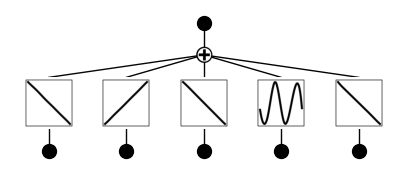

In [ ]:
model.plot()

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.3112e+00,  7.2052e-01,  4.0759e-01,  6.3297e-02, -6.9492e-02,
          -1.3125e-01, -7.9175e-03,  2.5845e-03]],

        [[-1.7849e+00, -1.3860e+00, -6.6246e-01, -1.8773e-01,  2.2796e-01,
           4.3063e-01,  6.2075e-01,  5.2986e-01]],

        [[ 1.3409e+00,  9.5636e-01,  4.3605e-01,  7.6219e-02, -1.4172e-01,
          -2.1443e-01, -1.9973e-01,  3.1275e-03]],

        [[ 3.0595e+00, -4.8333e-01, -8.4864e-01,  1.4773e+00, -1.3165e+00,
           4.3479e-01,  1.1103e+00, -5.4682e+00]],

        [[ 1.6612e+00,  8.1083e-01,  4.1879e-01,  1.1066e-01, -8.2183e-02,
          -9.3971e-02, -2.6204e-02,  3.1117e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[-1.2633e+00],
        [ 9.4045e-01],
        [-1.2728e+00],
        [-4.3539e-06],
        [-1.5160e+00]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.7720],
        [0.5513],
        [0.7411],
        [1.5380],
        [0.8202]], device='cuda:0')
act_fun.0.logits tensor([[[ 1.6744e-04,  3.4187e+00,

# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

In [9]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [10]:
def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

In [11]:
def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

In [ ]:
def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций
    lamb_ent_acts = 1e-3  # для энтропии активаций

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=5.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-3, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)
                    rounded_probs = probs.round(decimals=3)
                    print(rounded_probs)
        

## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [27]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


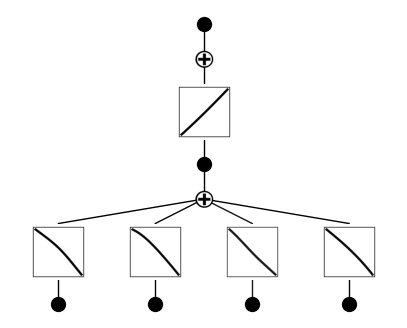

In [28]:
model = nexusKAN(width=[4, 1, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [29]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [10/1000], Train Loss: 3.5843, Test Loss: 3.2067
tensor([[[0.3010, 0.2700, 0.4290]],

        [[0.2750, 0.3240, 0.4010]],

        [[0.2870, 0.3160, 0.3970]],

        [[0.3220, 0.3010, 0.3770]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [20/1000], Train Loss: 1.3817, Test Loss: 1.6622
tensor([[[0.2990, 0.2690, 0.4320]],

        [[0.2730, 0.3230, 0.4040]],

        [[0.2850, 0.3150, 0.4000]],

        [[0.3210, 0.3000, 0.3790]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [30/1000], Train Loss: 0.8630, Test Loss: 1.1626
tensor([[[0.3050, 0.2740, 0.4210]],

        [[0.2750, 0.3280, 0.3970]],

        [[0.2900, 0.3210, 0.3890]],

        [[0.3260, 0.3040, 0.3700]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [40/1000], Train Loss: 0.6095, Test Loss: 0.9295
tensor([[[0.3050, 0.2740, 0

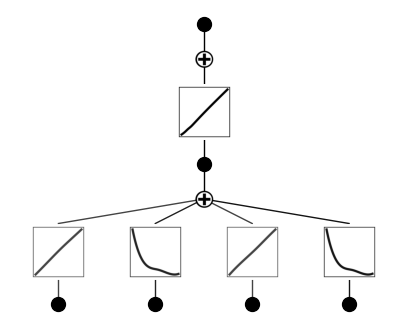

In [30]:
model.plot()

In [31]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [32]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [33]:
model = nexusKAN(width=[2, 1, 1], grid=5, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [34]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=2000)

Epoch [10/2000], Train Loss: 1.5963, Test Loss: 1.4440
tensor([[[0.5800, 0.4200]],

        [[0.5800, 0.4200]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [20/2000], Train Loss: 0.5415, Test Loss: 0.4483
tensor([[[0.5730, 0.4270]],

        [[0.5730, 0.4270]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [30/2000], Train Loss: 0.2531, Test Loss: 0.1587
tensor([[[0.5800, 0.4200]],

        [[0.5800, 0.4200]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [40/2000], Train Loss: 0.1012, Test Loss: 0.0751
tensor([[[0.5760, 0.4240]],

        [[0.5760, 0.4240]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [50/2000], Train Loss: 0.0472, Test Loss: 0.0265
tensor([[[0.5660, 0.4340]],

        [[0.5660, 0.4340]]], device='cuda:0', grad_f

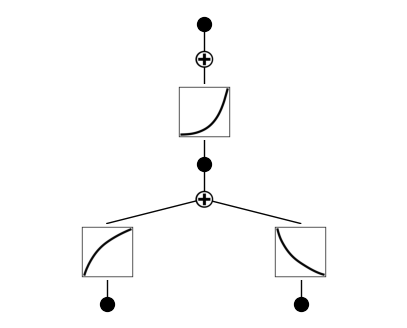

In [35]:
model.plot()

In [36]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1.]],

        [[0., 1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [51]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [52]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [53]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=2000)

Epoch [10/2000], Train Loss: 244.0827, Test Loss: 180.7818
tensor([[[0.2910, 0.2810, 0.4270],
         [0.2860, 0.3110, 0.4030]],

        [[0.3010, 0.2820, 0.4170],
         [0.2880, 0.3210, 0.3910]],

        [[0.2770, 0.2770, 0.4470],
         [0.3000, 0.3210, 0.3780]],

        [[0.2890, 0.2950, 0.4160],
         [0.2880, 0.2870, 0.4250]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.3990, 0.6010]],

        [[0.4350, 0.5650]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [20/2000], Train Loss: 103.3870, Test Loss: 62.6298
tensor([[[0.3110, 0.3000, 0.3880],
         [0.2970, 0.3250, 0.3770]],

        [[0.3190, 0.2980, 0.3840],
         [0.2980, 0.3350, 0.3670]],

        [[0.2950, 0.2940, 0.4110],
         [0.3100, 0.3340, 0.3550]],

        [[0.3090, 0.3140, 0.3770],
         [0.2980, 0.3000, 0.4020]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.4080, 0.5920]],

        [[0.4440, 0.5560]]], device='cuda:0', grad_fn=<RoundBackward1>)
Epoch [30/2000], Tr

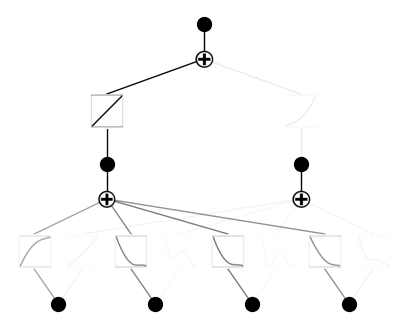

In [54]:
model.plot()

In [56]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.5620, 0.4370, 0.0020],
         [0.0000, 0.0000, 1.0000]],

        [[0.4940, 0.5050, 0.0010],
         [0.0000, 0.0000, 1.0000]],

        [[0.4890, 0.5100, 0.0010],
         [1.0000, 0.0000, 0.0000]],

        [[0.0000, 1.0000, 0.0000],
         [0.0000, 0.0000, 1.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1., 0.]],

        [[1., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [42]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


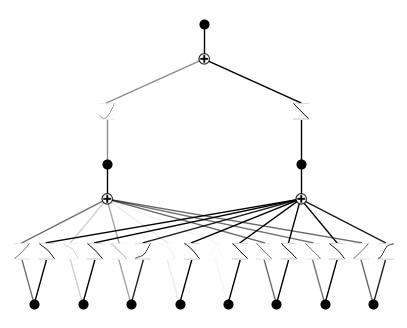

In [43]:
model = nexusKAN(width=[8, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [44]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=2000)

Epoch [10/2000], Train Loss: 2.3911, Test Loss: 2.2549
tensor([[[0.2080, 0.1830, 0.1890, 0.1940, 0.2260],
         [0.1990, 0.2030, 0.2070, 0.2150, 0.1760]],

        [[0.2040, 0.1900, 0.1910, 0.1930, 0.2220],
         [0.1840, 0.2130, 0.1990, 0.2160, 0.1880]],

        [[0.1880, 0.2150, 0.1980, 0.1950, 0.2040],
         [0.1920, 0.2170, 0.2100, 0.2200, 0.1620]],

        [[0.2080, 0.1780, 0.1890, 0.1960, 0.2280],
         [0.2190, 0.2180, 0.1880, 0.2040, 0.1720]],

        [[0.1930, 0.1800, 0.2140, 0.1810, 0.2330],
         [0.2080, 0.2010, 0.1910, 0.2170, 0.1830]],

        [[0.2040, 0.1820, 0.2090, 0.1960, 0.2090],
         [0.2300, 0.2040, 0.2010, 0.1900, 0.1760]],

        [[0.2140, 0.1950, 0.1900, 0.1940, 0.2070],
         [0.2090, 0.2140, 0.1840, 0.2030, 0.1890]],

        [[0.1950, 0.1830, 0.2010, 0.2010, 0.2190],
         [0.2080, 0.2040, 0.2150, 0.2060, 0.1670]]], device='cuda:0',
       grad_fn=<RoundBackward1>)
tensor([[[0.4280, 0.5720]],

        [[0.4050, 0.5950]]], devic

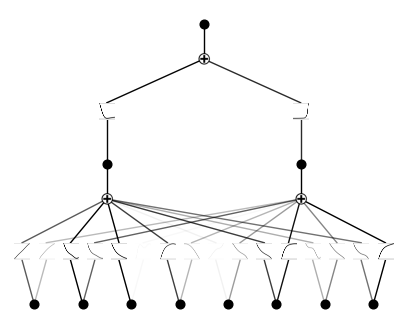

In [45]:
model.plot()

In [46]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0010, 0.6700, 0.0030, 0.3260]],

        [[0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9990, 0.0000, 0.0010]],

        [[0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0010, 0.0000, 0.9990, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 0.0000, 1.0000, 0.0000]],

        [[0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.0450, 0.0000, 0.9550, 0.0000, 0.0000]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.6860, 0.0000, 0.3140, 0.0000]],

        [[0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
         [0.0000, 0.0000, 0.9780, 0.0000, 0.0220]]], device='cuda:0',
       grad_fn=<RoundBackward1>)
tensor([[[1., 0.]],

        [[1., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
